In [1]:
import sys
from pathlib import Path
import json
import random

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score
from tensorflow.keras.applications.efficientnet import preprocess_input

from src.data_pipeline_augmented import prepare_data

In [ ]:
MODEL_PATH = PROJECT_ROOT / "experiments" / "results" / "best_efficientnetb0_augmented.keras"
RL_RESULTS_PATH = PROJECT_ROOT / "experiments" / "results" / "rl_results.json"
REWARD_PLOT_PATH = PROJECT_ROOT / "experiments" / "logs" / "rl_reward_curve.png"
F1_PLOT_PATH = PROJECT_ROOT / "experiments" / "logs" / "rl_f1_curve.png"
THRESHOLD_PLOT_PATH = PROJECT_ROOT / "experiments" / "logs" / "rl_threshold_curve.png"

In [3]:
data = prepare_data()
train_ds = data["train_ds"]
val_ds = data["val_ds"]
class_names = data["class_names"]

Found 5055 files belonging to 4 classes.
Found 1537 files belonging to 4 classes.


In [ ]:
model = tf.keras.models.load_model(
    str(MODEL_PATH),
    custom_objects={"preprocess_input": preprocess_input},
    compile=False,
)

In [5]:
X_val_batches = []
y_val_batches = []

for images, labels in val_ds:
    X_val_batches.append(images.numpy())
    y_val_batches.append(labels.numpy())

X_val = np.concatenate(X_val_batches, axis=0)
y_val_true = np.concatenate(y_val_batches, axis=0)

In [6]:
val_probs = model.predict(X_val, verbose=1)
val_pred = np.argmax(val_probs, axis=1)

base_acc = accuracy_score(y_val_true, val_pred)
base_f1 = f1_score(y_val_true, val_pred, average="macro")

print("Base accuracy:", round(base_acc, 4))
print("Base macro-F1:", round(base_f1, 4))

49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 303ms/step
Base accuracy: 0.9935
Base macro-F1: 0.9899


In [7]:
train_labels = []
for _, labels in train_ds:
    train_labels.extend(labels.numpy())

train_labels = np.array(train_labels)
fallback_class = int(np.bincount(train_labels).argmax())

print("Fallback class index:", fallback_class)
print("Fallback class name:", class_names[fallback_class])

Fallback class index: 2
Fallback class name: leaf_blast


In [8]:
class ThresholdEnv:
    def __init__(self, probs, y_true, threshold_values=None, fallback_class=0):
        self.probs = probs
        self.y_true = y_true
        self.num_classes = probs.shape[1]
        self.fallback_class = fallback_class

        if threshold_values is None:
            self.threshold_values = np.round(np.arange(0.00, 0.96, 0.05), 2)
        else:
            self.threshold_values = threshold_values

        self.state_idx = None
        self.base_f1 = self.evaluate_threshold(0.00)

    def reset(self):
        self.state_idx = len(self.threshold_values) // 2
        return self.state_idx

    def get_threshold(self):
        return self.threshold_values[self.state_idx]

    def step(self, action):
        old_score = self.evaluate_threshold(self.get_threshold())

        if action == 0:
            self.state_idx = max(0, self.state_idx - 1)
        elif action == 2:
            self.state_idx = min(len(self.threshold_values) - 1, self.state_idx + 1)

        new_threshold = self.get_threshold()
        new_score = self.evaluate_threshold(new_threshold)

        reward = new_score - old_score
        done = False

        return self.state_idx, reward, done, {
            "threshold": float(new_threshold),
            "macro_f1": float(new_score),
        }

    def evaluate_threshold(self, threshold):
        preds = []

        for p in self.probs:
            top_idx = np.argmax(p)
            top_conf = np.max(p)

            if top_conf >= threshold:
                preds.append(top_idx)
            else:
                preds.append(self.fallback_class)

        preds = np.array(preds)
        return f1_score(self.y_true, preds, average="macro")

In [9]:
env = ThresholdEnv(
    probs=val_probs,
    y_true=y_val_true,
    fallback_class=fallback_class,
)

In [10]:
num_states = len(env.threshold_values)
num_actions = 3
Q = np.zeros((num_states, num_actions))

alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.98
epsilon_min = 0.05

episodes = 50
steps_per_episode = 10

episode_rewards = []
episode_thresholds = []
episode_f1s = []

In [11]:
for episode in range(episodes):
    state = env.reset()
    total_reward = 0

    for _ in range(steps_per_episode):
        if random.random() < epsilon:
            action = random.randint(0, num_actions - 1)
        else:
            action = np.argmax(Q[state])

        next_state, reward, done, info = env.step(action)

        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state
        total_reward += reward

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    episode_rewards.append(float(total_reward))
    episode_thresholds.append(float(info["threshold"]))
    episode_f1s.append(float(info["macro_f1"]))

    print(
        f"Episode {episode+1:02d} | "
        f"Threshold: {info['threshold']:.2f} | "
        f"Macro-F1: {info['macro_f1']:.4f} | "
        f"Reward: {total_reward:.4f} | "
        f"Epsilon: {epsilon:.4f}"
    )

Episode 01 | Threshold: 0.80 | Macro-F1: 0.9855 | Reward: -0.0044 | Epsilon: 0.9800
Episode 02 | Threshold: 0.50 | Macro-F1: 0.9899 | Reward: 0.0000 | Epsilon: 0.9604
Episode 03 | Threshold: 0.60 | Macro-F1: 0.9908 | Reward: 0.0009 | Epsilon: 0.9412
Episode 04 | Threshold: 0.55 | Macro-F1: 0.9902 | Reward: 0.0003 | Epsilon: 0.9224
Episode 05 | Threshold: 0.45 | Macro-F1: 0.9899 | Reward: 0.0000 | Epsilon: 0.9039
Episode 06 | Threshold: 0.55 | Macro-F1: 0.9902 | Reward: 0.0003 | Epsilon: 0.8858
Episode 07 | Threshold: 0.65 | Macro-F1: 0.9908 | Reward: 0.0009 | Epsilon: 0.8681
Episode 08 | Threshold: 0.65 | Macro-F1: 0.9908 | Reward: 0.0009 | Epsilon: 0.8508
Episode 09 | Threshold: 0.45 | Macro-F1: 0.9899 | Reward: 0.0000 | Epsilon: 0.8337
Episode 10 | Threshold: 0.45 | Macro-F1: 0.9899 | Reward: 0.0000 | Epsilon: 0.8171
Episode 11 | Threshold: 0.40 | Macro-F1: 0.9899 | Reward: 0.0000 | Epsilon: 0.8007
Episode 12 | Threshold: 0.50 | Macro-F1: 0.9899 | Reward: 0.0000 | Epsilon: 0.7847
Epi

In [12]:
best_episode_idx = int(np.argmax(episode_f1s))
best_threshold = episode_thresholds[best_episode_idx]
best_f1 = episode_f1s[best_episode_idx]

print("Best threshold:", best_threshold)
print("Best macro-F1:", best_f1)

Best threshold: 0.6
Best macro-F1: 0.9907702621361898


In [13]:
final_state = env.reset()
for _ in range(10):
    action = np.argmax(Q[final_state])
    final_state, reward, done, info = env.step(action)

final_threshold = float(info["threshold"])
final_macro_f1 = float(info["macro_f1"])

print("Final policy threshold:", final_threshold)
print("Final policy macro-F1:", final_macro_f1)

Final policy threshold: 0.6
Final policy macro-F1: 0.9907702621361898


In [14]:
RL_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

with open(RL_RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {
            "base_accuracy": float(base_acc),
            "base_macro_f1": float(base_f1),
            "base_threshold": 0.0,
            "best_threshold": float(best_threshold),
            "best_macro_f1": float(best_f1),
            "final_policy_threshold": float(final_threshold),
            "final_policy_macro_f1": float(final_macro_f1),
            "fallback_class": str(class_names[fallback_class]),
        },
        f,
        indent=2,
    )

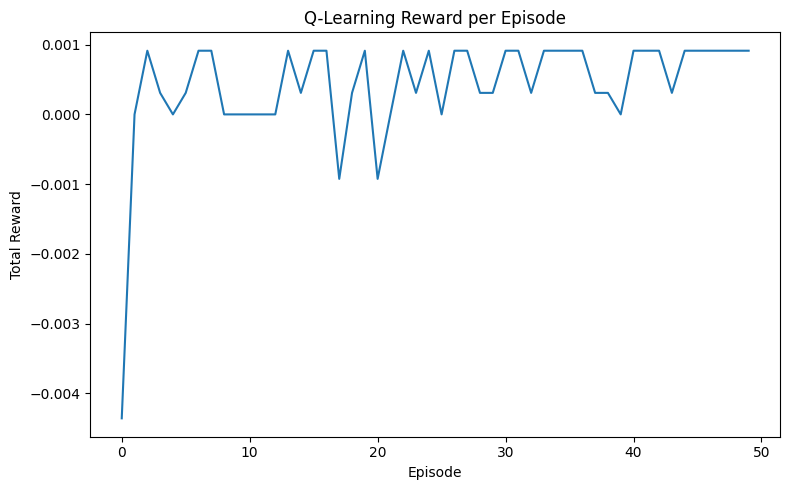

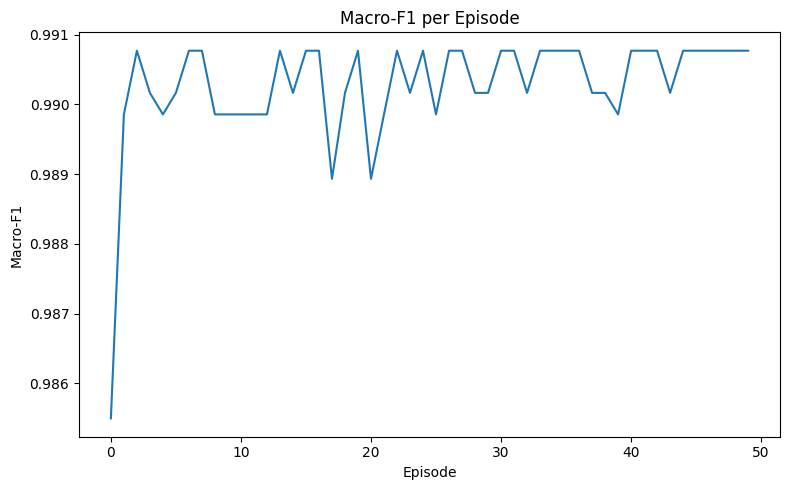

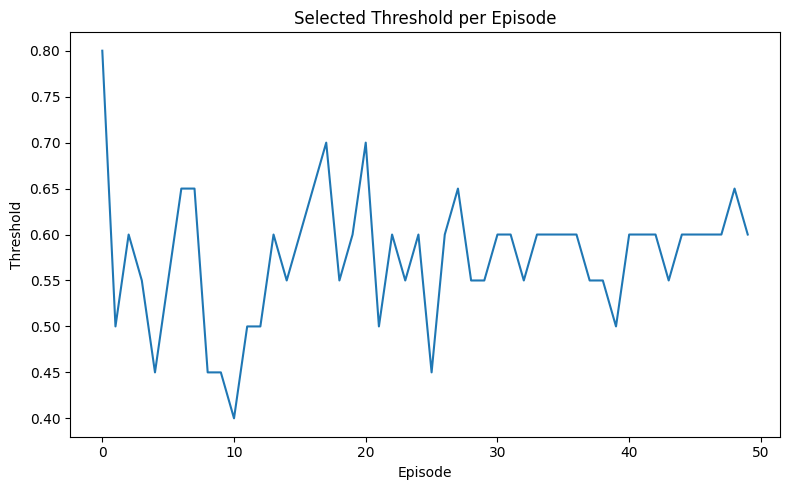

In [15]:
def plot_curve(values, title, ylabel, path):
    path.parent.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(8, 5))
    plt.plot(values)
    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

plot_curve(episode_rewards, "Q-Learning Reward per Episode", "Total Reward", REWARD_PLOT_PATH)
plot_curve(episode_f1s, "Macro-F1 per Episode", "Macro-F1", F1_PLOT_PATH)
plot_curve(episode_thresholds, "Selected Threshold per Episode", "Threshold", THRESHOLD_PLOT_PATH)